# exp1.ipynb
## Experiment Analysis for Training ML Based on Supervised Data and Optimizing Reward Functions (RNN)
### Purpose
The purpose of this notebook is to begin training and understanding the data received from experimentation in building a multiclass classifier model for tip conditions. The main source of the reinforcement learning in this notebook will be from other libraries, such as torch and scitools, but the following experiment outline identifies how we have set up data collection for training.

### Experimental Methodology
Classify a new tip/cantilever pair into a "good" condition class, and using a calibration sample material, iteratively take images while gradually increasing tip pressure and speed to induce wear on the tip. Classify images by their index number, i.e. images 1-4 will be considered in the "good" class, while images 5-8 "worse", and so on until image 17-20, where we classify the tip as "worn out/broken."

The training of a ML model to take a sample image and classify the wear of the tip will follow standard statistical outliers and the ability for the model to take periodic samples from trace and retrace data to make a prediction as a trend. This assumes that the **tip behavior does not change very much within single image scans, but does in the set of 20 scans**. So, the goal of this notebook is to be able to feed the model some sample of image scan data and have it predict the wear status of the tip.

Other important metrics that fuel the decision of the model can be used to point to the causes for tip wear, although it is likely that the scan number will be the main cause.

### Workflow
The main workflow for this notebook follows research on using reinforcement learning and supervised training as a hybrid approach to building a classifier model.

We will start with using a pre-trained image detection model, such as ImageNetV2 (https://imagenetv2.org/), and reinforcing its classification with trained data. The goal is to optimize some reward function, which we will experimentally define.

Ultimately, after discussion, it appears that that the most important metrics to classification will be:
+ **MAE of the trace/retrace in the height plot**.
+ **Standard deviation of the phase, or the variance of the hysteresis curve, where applicable**.
+ **Index number and supervised classification of tip condition**
+ **Scan rate and pressure on the tip**

**So, we should start with importing a pre-trained image model. The choice here will be ImageNet.**


In [ ]:
import torch                                        # For ML libraries/training
import torchvision.models as models                 # For accessing vision/image-based models


In [2]:
model = models.resnet18(weights='IMAGENET1K_V1')    # Load the pre-trained model (ResNet18)
model.eval()

"""
The "IMAGENET1K_V1 tells PyTorch to configure the model based on ImageNet weights.
"""

'\nThe "IMAGENET1K_V1 tells PyTorch to configure the model based on ImageNet weights.\n'

There is some consideration about cost and speed for training this model. Since image-based models are quite resource intensive (as any large model may be), it is generally recommended to use hardware acceleration from GPUs. For now, we will attempt to use local hardware (Apple Silicon) to train and process this model.

In [3]:
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

We will likely need to process .ibw files and open them as pandas dataframes or other relevant datastructures, then resize and normalize to fit the model for training. We can then define the reward function for reinforcement learning.


In [ ]:
import numpy as np

def reward_function(height_trace, height_retrace, 
                     phase_trace, phase_retrace, 
                     scan_index, scan_rate):
    """
    Computes a composite reward based on:
    - Mean Absolute Error (MAE) between forward and backward height signals
    - Standard deviation of the phase difference
    - A small penalty for higher scan rate (since faster scanning may produce more artifacts)

    The weights can be tuned to reflect their relative importance.
    """

    # 1. MAE Between Trace and Retrace Height
    mae = np.mean(np.abs(height_trace - height_retrace))

    # 2. Std Dev of Phase Difference Between Trace and Retrace
    phase_diff = phase_trace - phase_retrace
    phase_std = np.std(phase_diff)

    # 3. Penalty for Higher Scan Rate, 0.05 set to scale impact on function
    scan_rate_penalty = 0.05 * scan_rate

    # Define some customizable weights for scaling the reward function
    weights = [1, 1, 1]

    # Combine into a composite score.  
    # So we take the negative to make it a "reward" (higher is better).
    composite = -(weights[0] * mae + weights[1] * phase_std + weights[2] * scan_rate_penalty)

    return composite

File : sample_data/good_images/HeightCali0027.ibw
Imaging Mode : AC Mode
Scan Size : 2e-05
Header keys : ['ScanSize', 'FastScanSize', 'SlowScanSize', 'ScanRate', 'XOffset', 'YOffset', 'PointsLines', 'ScanPoints', 'ScanLines', 'ScanAngle', 'ImagingMode', 'InvOLS', 'SpringConstant', 'AmpInvOLS', 'Amp2Invols', 'FastRatio', 'SlowRatio', 'TopLine', 'BottomLine', 'ScanMode', 'NapMode', 'FMapScanTime', 'FMapScanPoints', 'FMapScanLines', 'FMapXYVelocity', 'FMapBookWise', 'Channel1DataType', 'DataTypeSum', 'PhaseOffset', 'PhaseOffset1', 'NapPhaseOffset', 'VoltageParm', 'NapParms', 'PreScanSetting', 'OrcaOffset', 'OrcaOffset2', 'UserIn0Gain', 'UserIn0Offset', 'UserIn1Gain', 'UserIn1Offset', 'UserIn2Gain', 'UserIn2Offset', 'LateralGain', 'LateralOffset', 'OrcaGain', 'OrcaGain2', 'FastMapScanRate', 'FastMapZRate', 'dcdvPhaseOffset', 'dcdZPhaseOffset', 'FastReturnLines', 'BackPackIn0Offset', 'BackPackIn0Gain', 'BackPackIn1Offset', 'BackPackIn1Gain', 'BackPackIn2Offset', 'BackPackIn2Gain', 'BackPack

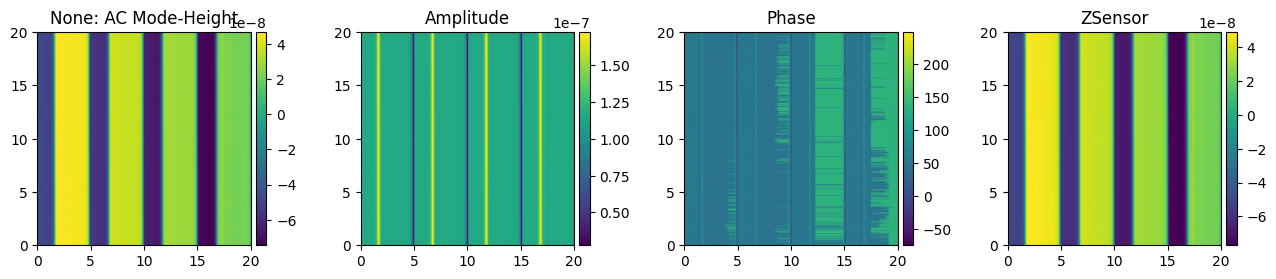

In [ ]:
import aespm.tools as at

def summarize_ibw_file(filename):
    """
    Prints a summary of information available in a .ibw file.
    """

    ibw = at.load_ibw(filename)

    print("File :", filename)
    print("Imaging Mode :", ibw.mode)
    print("Scan Size :", ibw.size)
    print("Header keys :", list(ibw.header.keys()))
    print("Available Channels :", ibw.channels)
    print("Data Shape :", ibw.data.shape)

    return ibw

ibw = summarize_ibw_file('sample_data/good_images/WTV_Loc010_0001.ibw')
at.display_ibw('sample_data/good_images/WTV_Loc010_0001.ibw')


In [14]:
import numpy as np

def compute_reward(ibw_data, trace_idx=0, retrace_idx=1):
    """
    Compute reward based on IBWData object.
    - ibw_data: your loaded IBWData instance with attributes:
      .data shape (channels, H, W), channels named in ibw_data.channels
    - trace_idx and retrace_idx: indices corresponding to trace and retrace data slices,
      if separate. If not separate, you may need to infer or segment.
    
    Returns:
        reward (float): higher is better
    """
    # Extract channels indices
    ch_names = ibw_data.channels
    
    # Height channel data: shape (H, W)
    height = ibw_data.data[ch_names.index('Height')]  # (H, W)
    
    # For trace vs retrace, you might split along one axis or have separate scans:
    # For now, assume trace = left half, retrace = right half
    mid = height.shape[1] // 2
    trace = height[:, :mid]
    retrace = height[:, mid:]
    
    # MAE between trace and retrace heights
    mae_height = np.mean(np.abs(trace - retrace))
    
    # Phase channel noise (std dev of phase difference trace vs retrace)
    phase = ibw_data.data[ch_names.index('Phase')]
    phase_trace = phase[:, :mid]
    phase_retrace = phase[:, mid:]
    phase_noise = np.std(phase_trace - phase_retrace)
    
    # Metadata: scan rate (normalize reward by it)
    scan_rate = ibw_data.header.get('ScanRate', 1.0)  # fallback to 1.0 if missing
    
    # Compose reward: inverse of error & noise, normalized by scan rate
    reward = 1 / (mae_height + 1e-6) + 1 / (phase_noise + 1e-6)
    reward /= scan_rate
    
    return reward

compute_reward(ibw)


np.float32(970979.4)

In [16]:
import torch.nn as nn
import torchvision.models as models

model = models.resnet18(pretrained=True)

# Replace final layer for custom number of classes (e.g., 10)
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import aespm.tools as at  # your IBW loader module
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report

# --- Dataset class for loading IBW files ---
class IBWDataset(Dataset):
    def __init__(self, ibw_files, labels=None, transform=None, compute_rewards=False):
        self.ibw_files = ibw_files
        self.labels = labels
        self.transform = transform
        self.compute_rewards = compute_rewards
        
        # Pre-compute rewards if needed for efficiency
        if compute_rewards:
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                ibw_data = at.load_ibw(file_path)
                reward = compute_reward(ibw_data, scan_index=i+1)
                self.rewards.append(reward)

    def __len__(self):
        return len(self.ibw_files)

    def __getitem__(self, idx):
        file_path = self.ibw_files[idx]
        ibw_data = at.load_ibw(file_path)
        height_img = ibw_data.z  
        img_tensor = preprocess_height_channel(height_img, self.transform)

        result = [img_tensor]
        
        if self.labels is not None:
            result.append(self.labels[idx])
        
        if self.compute_rewards:
            result.append(self.rewards[idx])
        
        # Always include scan index for reward computation
        result.append(idx + 1)  # scan_index starts from 1
            
        return tuple(result)

def custom_collate(batch):
    """
    Handle variable batch contents based on what's included
    """
    batch_size = len(batch)
    item_count = len(batch[0])
    
    imgs = torch.stack([item[0] for item in batch], dim=0)
    
    result = [imgs]
    
    if item_count >= 2:  # has labels
        labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
        result.append(labels)
    
    if item_count >= 3:  # has rewards
        rewards = torch.tensor([item[2] for item in batch], dtype=torch.float32)
        result.append(rewards)
    
    if item_count >= 4:  # has scan indices
        scan_indices = torch.tensor([item[-1] for item in batch], dtype=torch.long)
        result.append(scan_indices)
    
    return tuple(result)

# --- Preprocessing function to convert height data to 3-channel tensor ---
def preprocess_height_channel(height_np_array, transform=None):
    """
    Normalize the Height channel to [0, 255], convert to PIL Image,
    duplicate single channel to 3 channels, apply transforms.
    """
    # Normalize to 0-255
    h_min = np.min(height_np_array)
    h_max = np.max(height_np_array)
    norm_img = 255 * (height_np_array - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)

    # Convert to PIL image
    pil_img = Image.fromarray(norm_img)

    # Convert grayscale to RGB by duplicating channels
    pil_img = pil_img.convert("RGB")

    if transform:
        return transform(pil_img)
    else:
        # Default tensor transform if none given
        return transforms.ToTensor()(pil_img)

def compute_reward(ibw_data, scan_index=0):
    """
    ibw_data: loaded IBWData object with channels like Height, Phase, and header with scan rate
    scan_index: integer index of the scan (can be used as feature or penalty)

    Returns a scalar reward; higher is better
    """
    height = ibw_data.z            # Shape: (H, W)
    
    # Handle phase channel safely
    try:
        phase_idx = ibw_data.channels.index('Phase')
        phase = ibw_data.data[phase_idx]
    except (ValueError, IndexError):
        # If no Phase channel, use zeros or skip phase reward
        phase = np.zeros_like(height)
        print(f"Warning: No Phase channel found for scan {scan_index}")

    # Extract scan rate from header
    scan_rate = ibw_data.header.get('ScanRate', 1.0)  # default 1.0 if missing

    # Assuming scanning direction is along rows
    # Split trace and retrace along rows
    trace = height[::2, :]    # even rows: trace
    retrace = height[1::2, :] # odd rows: retrace

    # Calculate MAE between trace and retrace (must be same shape)
    min_rows = min(trace.shape[0], retrace.shape[0])
    if min_rows > 0:
        mae_height = np.mean(np.abs(trace[:min_rows, :] - retrace[:min_rows, :]))
    else:
        mae_height = 0.0

    # Same split for phase
    phase_trace = phase[::2, :]
    phase_retrace = phase[1::2, :]
    min_rows_phase = min(phase_trace.shape[0], phase_retrace.shape[0])

    if min_rows_phase > 0:
        # Calculate combined phase std deviation (how much phase differs between trace and retrace)
        phase_diff = phase_trace[:min_rows_phase, :] - phase_retrace[:min_rows_phase, :]
        phase_std = np.std(phase_diff)
    else:
        phase_std = 0.0

    # Normalize and invert metrics to reward higher quality
    # Smaller mae_height and phase_std means better => higher reward
    mae_reward = 1 / (mae_height + 1e-6)
    phase_reward = 1 / (phase_std + 1e-6)

    # Index penalty: higher indices (worse quality) get lower rewards
    index_penalty = 1 / (scan_index + 1)

    # Scan rate reward (if you know preferred rate, e.g. 1.0)
    preferred_rate = 1.0
    scan_rate_reward = np.exp(-abs(scan_rate - preferred_rate))

    # Combine all with weights (adjust weights as needed)
    reward = 0.4 * mae_reward + 0.4 * phase_reward + 0.1 * index_penalty + 0.1 * scan_rate_reward

    return reward

def generate_labels_from_scan_indices(scan_indices, group_size=4):
    """
    Generate classification labels based on scan indices
    Groups of 4: 1-4 (class 0, good), 5-8 (class 1), 9-12 (class 2), 13-16 (class 3), 17-20 (class 4, bad)
    """
    labels = []
    for idx in scan_indices:
        # Convert 1-based index to 0-based, then divide by group_size
        label = min((idx - 1) // group_size, 4)  # Cap at class 4
        labels.append(label)
    return labels

# --- Enhanced Model with Reward Prediction Head ---
class RewardAwareModel(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(RewardAwareModel, self).__init__()
        # Base model
        self.backbone = models.resnet18(pretrained=pretrained)
        
        # Remove the final classification layer
        self.features = nn.Sequential(*list(self.backbone.children())[:-1])
        
        # Get feature dimension
        feature_dim = self.backbone.fc.in_features
        
        # Classification head
        self.classifier = nn.Linear(feature_dim, num_classes)
        
        # Reward prediction head (optional - for multi-task learning)
        self.reward_predictor = nn.Linear(feature_dim, 1)
        
    def forward(self, x, return_features=False):
        # Extract features
        features = self.features(x)
        features = torch.flatten(features, 1)
        
        # Classification output
        class_output = self.classifier(features)
        
        # Reward prediction output
        reward_output = self.reward_predictor(features)
        
        if return_features:
            return class_output, reward_output, features
        else:
            return class_output, reward_output

# --- Training function ---
def train_model(model, dataloader, optimizer, device, num_epochs=10, 
                classification_weight=1.0, reward_weight=0.1):
    model.train()
    
    classification_criterion = nn.CrossEntropyLoss()
    reward_criterion = nn.MSELoss()
    
    for epoch in range(num_epochs):
        running_class_loss = 0.0
        running_reward_loss = 0.0
        running_total_loss = 0.0
        
        for i, batch_data in enumerate(dataloader):
            # Unpack batch data
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:  # imgs, scan_indices
                inputs, scan_indices = batch_data
                labels = None
                rewards = None

            inputs = inputs.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            class_outputs, reward_outputs = model(inputs)
            
            total_loss = 0
            
            # Classification loss
            if labels is not None:
                labels = labels.to(device)
                class_loss = classification_criterion(class_outputs, labels)
                total_loss += classification_weight * class_loss
                running_class_loss += class_loss.item()
            
            # Reward prediction loss
            if rewards is not None:
                rewards = rewards.to(device).unsqueeze(1)  # Add dimension for MSE
                reward_loss = reward_criterion(reward_outputs, rewards)
                total_loss += reward_weight * reward_loss
                running_reward_loss += reward_loss.item()
            
            # Backward pass
            if total_loss > 0:
                total_loss.backward()
                optimizer.step()
                running_total_loss += total_loss.item()

        # Print epoch statistics
        avg_total_loss = running_total_loss / len(dataloader)
        avg_class_loss = running_class_loss / len(dataloader)
        avg_reward_loss = running_reward_loss / len(dataloader)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Total Loss: {avg_total_loss:.4f}")
        print(f"  Classification Loss: {avg_class_loss:.4f}")
        print(f"  Reward Loss: {avg_reward_loss:.4f}")
        print("-" * 40)

def evaluate_model(model, dataloader, device):
    """Evaluate the model and return metrics"""
    model.eval()
    all_predictions = []
    all_labels = []
    all_rewards_true = []
    all_rewards_pred = []
    
    with torch.no_grad():
        for batch_data in dataloader:
            if len(batch_data) == 4:  # imgs, labels, rewards, scan_indices
                inputs, labels, rewards, scan_indices = batch_data
            elif len(batch_data) == 3:  # imgs, labels, scan_indices
                inputs, labels, scan_indices = batch_data
                rewards = None
            else:
                continue  # Need at least labels for evaluation
                
            inputs = inputs.to(device)
            
            class_outputs, reward_outputs = model(inputs)
            
            # Get predictions
            _, predicted = torch.max(class_outputs.data, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
            if rewards is not None:
                all_rewards_true.extend(rewards.numpy())
                all_rewards_pred.extend(reward_outputs.cpu().numpy().flatten())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    print(f"Classification Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions))
    
    if all_rewards_true:
        reward_mse = np.mean((np.array(all_rewards_true) - np.array(all_rewards_pred))**2)
        print(f"Reward Prediction MSE: {reward_mse:.4f}")
    
    return accuracy

# --- Main script ---
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # # Example IBW file paths (replace with your actual files)
    # # Read all .ibw files from "exp_data/" and sort them by filename
    # ibw_folder = "exp_data/"
    # ibw_files = sorted(
    #     [os.path.join(ibw_folder, f) for f in os.listdir(ibw_folder) if f.lower().endswith(".ibw")]
    # )
    # print(f"Found {len(ibw_files)} IBW files in {ibw_folder}")

    # Example IBW file paths (replace with your actual files)
    ibw_files = [
        "sample_data/good_images/WTV_Loc001_0001.ibw",
        "sample_data/good_images/WTV_Loc002_0001.ibw",
        "sample_data/good_images/WTV_Loc003_0001.ibw",
        "sample_data/good_images/WTV_Loc004_0001.ibw",
        "sample_data/good_images/WTV_Loc005_0001.ibw",
        "sample_data/good_images/WTV_Loc006_0001.ibw",
        "sample_data/good_images/WTV_Loc007_0001.ibw",
        "sample_data/good_images/WTV_Loc008_0001.ibw",
        "sample_data/good_images/WTV_Loc009_0001.ibw",
        "sample_data/good_images/WTV_Loc010_0001.ibw",
        "sample_data/good_images/WTV_Loc011_0001.ibw",
        "sample_data/good_images/WTV_Loc012_0001.ibw",
        "sample_data/good_images/WTV_Loc013_0001.ibw",
        "sample_data/good_images/WTV_Loc014_0001.ibw",
        "sample_data/good_images/WTV_Loc015_0001.ibw",
        "sample_data/good_images/WTV_Loc016_0001.ibw",
        "sample_data/good_images/WTV_Loc017_0001.ibw",
        "sample_data/good_images/WTV_Loc018_0001.ibw",
        "sample_data/good_images/WTV_Loc019_0001.ibw",
        "sample_data/good_images/WTV_Loc020_0001.ibw"



        # Add your 20 files here, ordered by scan index 1-20
        # Files 1-4: good quality (class 0)
        # Files 5-8: medium-good quality (class 1)  
        # Files 9-12: medium quality (class 2)
        # Files 13-16: medium-bad quality (class 3)
        # Files 17-20: bad quality (class 4)
    ]
    
    # Generate scan indices (1-20)
    scan_indices = list(range(1, len(ibw_files) + 1))
    
    # Generate labels based on scan indices
    labels = generate_labels_from_scan_indices(scan_indices)
    print(f"Generated labels: {labels}")

    # Define transforms to match ImageNet normalization & size
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])

    # Create dataset with reward computation
    dataset = IBWDataset(ibw_files, labels, transform, compute_rewards=True)
    
    # Split dataset for training and validation
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=custom_collate)
    val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=custom_collate)

    # Create model
    model = RewardAwareModel(num_classes=5, pretrained=True)
    model = model.to(device)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    
    # Optional: Learning rate scheduler
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    print("Starting training...")
    train_model(model, train_dataloader, optimizer, device, 
                num_epochs=20, classification_weight=1.0, reward_weight=0.1)

    print("\nEvaluating on validation set...")
    evaluate_model(model, val_dataloader, device)
    
    # Save the trained model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }, 'ibw_reward_model.pth')
    
    print("Model saved as 'ibw_reward_model.pth'")

if __name__ == "__main__":
    main()

Using device: cpu
Generated labels: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]


/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Starting training...
Epoch 1/20
  Total Loss: 15942326528.0000
  Classification Loss: 1.7470
  Reward Loss: 159423262720.0000
----------------------------------------
Epoch 2/20
  Total Loss: 15942297600.0000
  Classification Loss: 1.5969
  Reward Loss: 159422971904.0000
----------------------------------------
Epoch 3/20
  Total Loss: 15942269952.0000
  Classification Loss: 1.6263
  Reward Loss: 159422697472.0000
----------------------------------------
Epoch 4/20
  Total Loss: 15942248960.0000
  Classification Loss: 1.5818
  Reward Loss: 159422488576.0000
----------------------------------------
Epoch 5/20
  Total Loss: 15942216448.0000
  Classification Loss: 1.5201
  Reward Loss: 159422160896.0000
----------------------------------------
Epoch 6/20
  Total Loss: 15942191360.0000
  Classification Loss: 1.5422
  Reward Loss: 159421911040.0000
----------------------------------------
Epoch 7/20
  Total Loss: 15942169856.0000
  Classification Loss: 1.4446
  Reward Loss: 159421698048.000

/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/colin/Documents/GitHub/ofdspm/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{

In [24]:
def predict_single_ibw(model, ibw_file_path, transform, device):
    """
    Predict quality class and reward for a single IBW file
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_path: Path to the IBW file
        transform: Image transforms to apply
        device: PyTorch device
    
    Returns:
        dict with prediction results
    """
    model.eval()
    
    try:
        # Load and preprocess the IBW file
        ibw_data = at.load_ibw(ibw_file_path)
        height_img = ibw_data.z
        img_tensor = preprocess_height_channel(height_img, transform)
        
        # Add batch dimension
        img_tensor = img_tensor.unsqueeze(0).to(device)
        
        with torch.no_grad():
            class_outputs, reward_outputs = model(img_tensor)
            
            # Get predicted class
            probabilities = torch.softmax(class_outputs, dim=1)
            predicted_class = torch.argmax(class_outputs, dim=1).item()
            confidence = probabilities[0, predicted_class].item()
            
            # Get predicted reward
            predicted_reward = reward_outputs.item()
            
            # Compute actual reward for comparison
            actual_reward = compute_reward(ibw_data, scan_index=0)  # Use 0 since it's unknown
            
        # Create quality description
        quality_descriptions = {
            0: "Excellent (scans 1-4)",
            1: "Good (scans 5-8)", 
            2: "Fair (scans 9-12)",
            3: "Poor (scans 13-16)",
            4: "Bad (scans 17-20)"
        }
        
        result = {
            'file_path': ibw_file_path,
            'predicted_class': predicted_class,
            'quality_description': quality_descriptions[predicted_class],
            'confidence': confidence,
            'class_probabilities': probabilities[0].cpu().numpy(),
            'predicted_reward': predicted_reward,
            'actual_reward': actual_reward,
            'reward_difference': abs(predicted_reward - actual_reward)
        }
        
        return result
        
    except Exception as e:
        return {
            'file_path': ibw_file_path,
            'error': str(e),
            'predicted_class': None
        }

def predict_multiple_ibw(model, ibw_file_paths, transform, device):
    """
    Predict quality for multiple IBW files
    
    Args:
        model: Trained RewardAwareModel
        ibw_file_paths: List of paths to IBW files
        transform: Image transforms to apply
        device: PyTorch device
    
    Returns:
        List of prediction results
    """
    results = []
    
    print(f"Predicting quality for {len(ibw_file_paths)} files...")
    
    for i, file_path in enumerate(ibw_file_paths):
        print(f"Processing file {i+1}/{len(ibw_file_paths)}: {file_path}")
        result = predict_single_ibw(model, file_path, transform, device)
        results.append(result)
        
        if 'error' not in result:
            print(f"  Predicted: Class {result['predicted_class']} ({result['quality_description']}) "
                  f"with {result['confidence']:.3f} confidence")
        else:
            print(f"  Error: {result['error']}")
    
    return results

def load_trained_model(model_path, num_classes=5, device='cpu'):
    """
    Load a trained model from saved checkpoint
    
    Args:
        model_path: Path to saved model (.pth file)
        num_classes: Number of quality classes
        device: PyTorch device
    
    Returns:
        Loaded model ready for inference
    """
    model = RewardAwareModel(num_classes=num_classes, pretrained=False)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    print(f"Model loaded from {model_path}")
    return model

def print_prediction_summary(results):
    """
    Print a nice summary of prediction results
    """
    print("\n" + "="*80)
    print("PREDICTION SUMMARY")
    print("="*80)
    
    # Count predictions by class
    class_counts = {i: 0 for i in range(5)}
    successful_predictions = 0
    
    for result in results:
        if 'error' not in result and result['predicted_class'] is not None:
            class_counts[result['predicted_class']] += 1
            successful_predictions += 1
    
    print(f"Successfully processed: {successful_predictions}/{len(results)} files")
    print("\nQuality Distribution:")
    quality_names = ["Excellent", "Good", "Fair", "Poor", "Bad"]
    
    for class_idx, count in class_counts.items():
        percentage = (count / successful_predictions * 100) if successful_predictions > 0 else 0
        print(f"  Class {class_idx} ({quality_names[class_idx]}): {count} files ({percentage:.1f}%)")
    
    print("\nDetailed Results:")
    print("-" * 80)
    
    for i, result in enumerate(results):
        if 'error' not in result:
            print(f"{i+1:2d}. {result['file_path']}")
            print(f"    Quality: {result['quality_description']}")
            print(f"    Confidence: {result['confidence']:.3f}")
            print(f"    Predicted Reward: {result['predicted_reward']:.4f}")
            print(f"    Actual Reward: {result['actual_reward']:.4f}")
            print(f"    Reward Error: {result['reward_difference']:.4f}")
        else:
            print(f"{i+1:2d}. {result['file_path']} - ERROR: {result['error']}")
        print()


Model loaded from ibw_reward_model.pth
Quality: Good (scans 5-8)
Confidence: 0.284
Predicted Class: 1


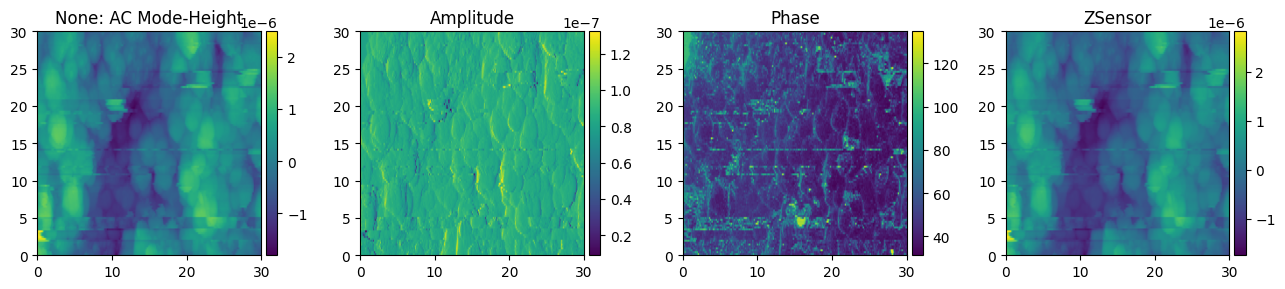

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_trained_model('ibw_reward_model.pth', num_classes=5, device=device)

# Define transforms (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Predict single file
file = "sample_data/bad_images/PositionC_30Cs70M0000.ibw"
result = predict_single_ibw(model, file, transform, device)
at.display_ibw(file)


print(f"Quality: {result['quality_description']}")
print(f"Confidence: {result['confidence']:.3f}")
print(f"Predicted Class: {result['predicted_class']}")